# TS4 - Estimacion de amplitud y frecuencia con ventanas espectrales

Se estudia el efecto de distintas ventanas sobre los estimadores de amplitud y frecuencia de una senoidal con frecuencia aleatoria y ruido aditivo.

Senal:
$$x(k) = a_0 \cdot \sin(\Omega_1 \cdot k) + n_a(k)$$

con $a_0 = \sqrt{2}$ (potencia unitaria), $\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$, $\Omega_0 = \pi/2$, $f_r \sim \mathcal{U}(-2,2)$, $n_a \sim \mathcal{N}(0,\sigma^2)$.

Estimadores:

$$\hat{a}_1^{(i)} = \frac{2\,|X_{w_i}(\Omega_0)|}{\sum_n w_i(n)}, \qquad \hat{\Omega}_1^{(i)} = \frac{2\pi}{N} \underset{k}{\arg\max}\{|X_{w_i}[k]|\}$$

Sesgo y varianza ($M = 200$ realizaciones):

$$s_a = \overline{\hat{a}} - a_0, \quad v_a = \frac{1}{M}\sum_j(\hat{a}_j - \overline{\hat{a}})^2, \quad s_\Omega = \overline{\hat{\Omega}_j - \Omega_{1,j}}, \quad v_\Omega = \text{var}\{\hat{\Omega}_j - \Omega_{1,j}\}$$

In [24]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

In [25]:
N   = 1000
M   = 200
fs  = 1000.0

Omega0 = np.pi / 2
k0 = int(round(N * Omega0 / (2 * np.pi)))   # bin 250
a0 = np.sqrt(2)

n = np.arange(N)

print(f'Omega0 = pi/2 = {Omega0:.6f} rad/muestra')
print(f'k0 = {k0}  (f0 = {k0*fs/N:.1f} Hz)')
print(f'a0 = sqrt(2) = {a0:.6f}  ->  Potencia = {a0**2/2:.4f} W')

Omega0 = pi/2 = 1.570796 rad/muestra
k0 = 250  (f0 = 250.0 Hz)
a0 = sqrt(2) = 1.414214  ->  Potencia = 1.0000 W


In [26]:
windows = {
    'Rectangular':     sig.windows.boxcar(N),
    'Flat-top':        sig.windows.flattop(N),
    'Blackman-Harris': sig.windows.blackmanharris(N),
    'Nuttall':         sig.windows.nuttall(N),
}

print(f'{"Ventana":>18} | {"sum(w)":>10} | {"Ganancia coh.":>14}')
print('-'*48)
for name, w in windows.items():
    print(f'{name:>18} | {np.sum(w):>10.4f} | {np.sum(w)/N:>14.6f}')

           Ventana |     sum(w) |  Ganancia coh.
------------------------------------------------
       Rectangular |  1000.0000 |       1.000000
          Flat-top |   215.3629 |       0.215363
   Blackman-Harris |   358.3913 |       0.358391
           Nuttall |   363.2187 |       0.363219


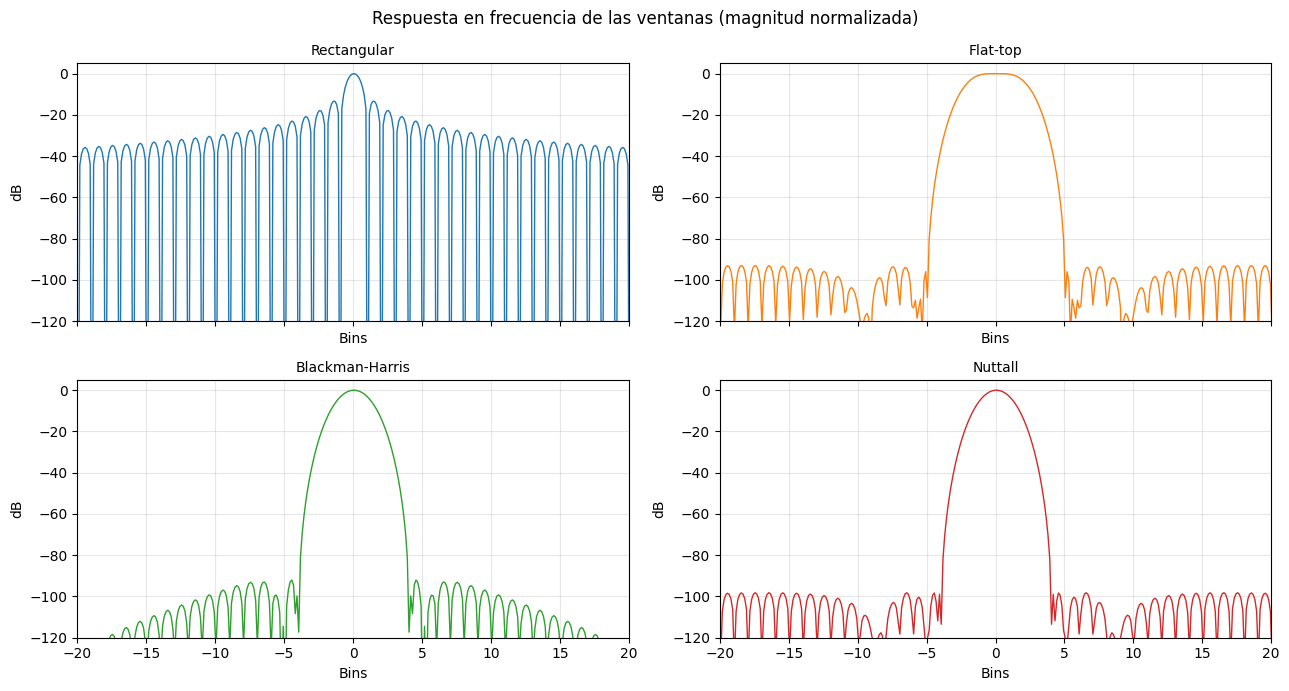

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
fig.suptitle('Respuesta en frecuencia de las ventanas (magnitud normalizada)', fontsize=12)
colors = ['C0', 'C1', 'C2', 'C3']

for ax, (name, w), color in zip(axes.flat, windows.items(), colors):
    W = np.fft.fftshift(np.fft.fft(w, n=8*N))
    bins = np.linspace(-0.5, 0.5, 8*N) * N
    W_dB = 20*np.log10(np.abs(W)/np.max(np.abs(W)) + 1e-12)
    ax.plot(bins, W_dB, color=color, lw=1)
    ax.set_xlim(-20, 20)
    ax.set_ylim(-120, 5)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Bins')
    ax.set_ylabel('dB')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Experimento Monte Carlo

Para cada SNR se generan $M = 200$ realizaciones con $f_r \sim \mathcal{U}(-2,2)$ y $n_a \sim \mathcal{N}(0,\sigma^2)$, con $\sigma^2 = 1/\text{SNR}_{\text{lin}}$ ya que $P_s = 1\,\text{W}$.

In [28]:
def run_experiment(snr_db, M=200, N=1000, seed=42):
    snr_lin = 10 ** (snr_db / 10)
    sigma = np.sqrt(1.0 / snr_lin)

    rng = np.random.default_rng(seed)
    fr_vals = rng.uniform(-2, 2, M)
    noise = rng.normal(0, sigma, (M, N))
    Omega1_true = Omega0 + fr_vals * 2*np.pi/N

    results = {}
    for name, w in windows.items():
        W_sum = np.sum(w)
        amp_est = np.empty(M)
        freq_est = np.empty(M)

        for j in range(M):
            x  = a0 * np.sin(Omega1_true[j] * n) + noise[j]
            Xw = np.fft.rfft(x * w)

            amp_est[j] = 2 * np.abs(Xw[k0]) / W_sum
            k_max = np.argmax(np.abs(Xw))
            freq_est[j] = k_max * 2*np.pi / N

        freq_err = freq_est - Omega1_true
        mu_a = np.mean(amp_est)

        results[name] = {
            'amp_est':      amp_est,
            'freq_est':     freq_est,
            'Omega1_true':  Omega1_true,
            'mu_a': mu_a,
            'sa':   mu_a - a0,
            'va':   np.var(amp_est),
            'sf':   np.mean(freq_err),
            'vf':   np.var(freq_err),
        }

    return results


res_3dB  = run_experiment(3)
res_10dB = run_experiment(10)
print('Listo.')

Listo.


In [29]:
def print_table(headers, rows, title):
    col_w = [max(len(h), max(len(r[i]) for r in rows)) + 2 for i, h in enumerate(headers)]
    sep = '+' + '+'.join('-'*w for w in col_w) + '+'
    fmt = '|' + '|'.join(f'{{:^{w}}}' for w in col_w) + '|'
    print(f'\n{title}')
    print(sep)
    print(fmt.format(*headers))
    print(sep)
    for row in rows:
        print(fmt.format(*row))
    print(sep)


def make_tables(results, snr_db):
    print(f'\nSNR = {snr_db} dB   (a0 = sqrt(2) = {a0:.5f},  P = 1 W)')

    headers_a = ['Ventana', 'E{a^}', 'sa (sesgo)', 'va (varianza)', 'sqrt(va)']
    rows_a = []
    for name, r in results.items():
        rows_a.append([
            name,
            f"{r['mu_a']:.5f}",
            f"{r['sa']:+.5f}",
            f"{r['va']:.2e}",
            f"{np.sqrt(r['va']):.5f}",
        ])
    print_table(headers_a, rows_a, 'Estimacion de Amplitud')

    headers_f = ['Ventana', 'sO [mrad/m]', 'vO [mrad2/m2]', 'sqrt(vO) [mrad/m]', 'sqrt(vO) [bins]']
    rows_f = []
    for name, r in results.items():
        rows_f.append([
            name,
            f"{r['sf']*1e3:+.4f}",
            f"{r['vf']*1e6:.4f}",
            f"{np.sqrt(r['vf'])*1e3:.4f}",
            f"{np.sqrt(r['vf'])*N/(2*np.pi):.5f}",
        ])
    print_table(headers_f, rows_f, 'Estimacion de Frecuencia')


make_tables(res_3dB,  3)
make_tables(res_10dB, 10)


SNR = 3 dB   (a0 = sqrt(2) = 1.41421,  P = 1 W)

Estimacion de Amplitud
+-----------------+---------+------------+---------------+----------+
|     Ventana     |  E{a^}  | sa (sesgo) | va (varianza) | sqrt(va) |
+-----------------+---------+------------+---------------+----------+
|   Rectangular   | 0.52546 |  -0.88875  |   2.11e-01    | 0.45960  |
|    Flat-top     | 1.30811 |  -0.10611  |   2.36e-02    | 0.15375  |
| Blackman-Harris | 0.94353 |  -0.47068  |   1.32e-01    | 0.36292  |
|     Nuttall     | 0.93437 |  -0.47985  |   1.35e-01    | 0.36795  |
+-----------------+---------+------------+---------------+----------+

Estimacion de Frecuencia
+-----------------+-------------+---------------+-------------------+-----------------+
|     Ventana     | sO [mrad/m] | vO [mrad2/m2] | sqrt(vO) [mrad/m] | sqrt(vO) [bins] |
+-----------------+-------------+---------------+-------------------+-----------------+
|   Rectangular   |   +0.0598   |    3.2230     |      1.7953       |     0.2

## Analisis de resultados

La flat-top tiene el lobulo principal muy ancho y plano, lo que la hace insensible a la desintonía $f_r \in [-2,2]$ bins: el sesgo de amplitud es minimo. Sin embargo, esa misma anchura perjudica la resolucion de frecuencia.

La rectangular maximiza la resolucion espectral (lobulo de 1 bin) pero al evaluar $|X_w(\Omega_0)|$ en el bin fijo $k_0 = 250$ en lugar del pico real, la atenuacion del sinc de Dirichlet produce sesgo de amplitud proporcional a $f_r$.

La Blackman-Harris y la Nuttall ofrecen un compromiso: lobulos laterales muy bajos ($< -92$ dB y $< -114$ dB respectivamente) con lobulo principal de unos 4 bins. El sesgo de amplitud es intermedio y la varianza de frecuencia tambien.

## Bonus - Zero padding en el estimador de frecuencia

Sin zero-padding el estimador solo puede tomar valores en la grilla $\Omega_k = 2\pi k/N$, con error de cuantizacion maximo $\pm\pi/N$ rad/muestra ($\pm 0.5$ bins). Con factor $\gamma$ la grilla se hace $\gamma$ veces mas densa y el error cae como $1/\gamma$ hasta que el piso lo fija el SNR.

In [30]:
def run_experiment_zp(snr_db, zp_factors=(1, 2, 4, 8, 16), M=200, seed=42):
    snr_lin = 10 ** (snr_db / 10)
    sigma = np.sqrt(1.0 / snr_lin)

    rng = np.random.default_rng(seed)
    fr_vals = rng.uniform(-2, 2, M)
    noise = rng.normal(0, sigma, (M, N))
    Omega1_true = Omega0 + fr_vals * 2*np.pi/N

    wins_zp = {
        'Rectangular':     sig.windows.boxcar(N),
        'Blackman-Harris': sig.windows.blackmanharris(N),
        'Flat-top':        sig.windows.flattop(N),
    }
    win_names = list(wins_zp.keys())

    data = {name: [] for name in win_names}
    for gamma in zp_factors:
        NFFT = gamma * N
        for name, w in wins_zp.items():
            freq_est = np.empty(M)
            for j in range(M):
                x   = a0 * np.sin(Omega1_true[j] * n) + noise[j]
                Xw  = np.fft.rfft(x * w, n=NFFT)
                k_m = np.argmax(np.abs(Xw))
                freq_est[j] = k_m * 2*np.pi / NFFT
            err = freq_est - Omega1_true
            data[name].append(np.sqrt(np.var(err)) * 1e3)

    headers = ['ZP factor'] + [f'{n} sqrt(vO) [mrad/m]' for n in win_names]
    rows = []
    for i, gamma in enumerate(zp_factors):
        rows.append([f'{gamma}x (NFFT={gamma*N})'] + [f'{data[n][i]:.4f}' for n in win_names])
    print_table(headers, rows, f'Zero Padding - SNR = {snr_db} dB')


run_experiment_zp(3)
run_experiment_zp(10)


Zero Padding - SNR = 3 dB
+------------------+-------------------------------+-----------------------------------+----------------------------+
|    ZP factor     | Rectangular sqrt(vO) [mrad/m] | Blackman-Harris sqrt(vO) [mrad/m] | Flat-top sqrt(vO) [mrad/m] |
+------------------+-------------------------------+-----------------------------------+----------------------------+
|  1x (NFFT=1000)  |            1.7953             |              1.7982               |           2.7711           |
|  2x (NFFT=2000)  |            0.9564             |              0.9617               |           2.8499           |
|  4x (NFFT=4000)  |            0.4701             |              0.5056               |           2.9539           |
|  8x (NFFT=8000)  |            0.2379             |              0.2802               |           2.9419           |
| 16x (NFFT=16000) |            0.1321             |              0.2123               |           2.9285           |
+------------------+---------

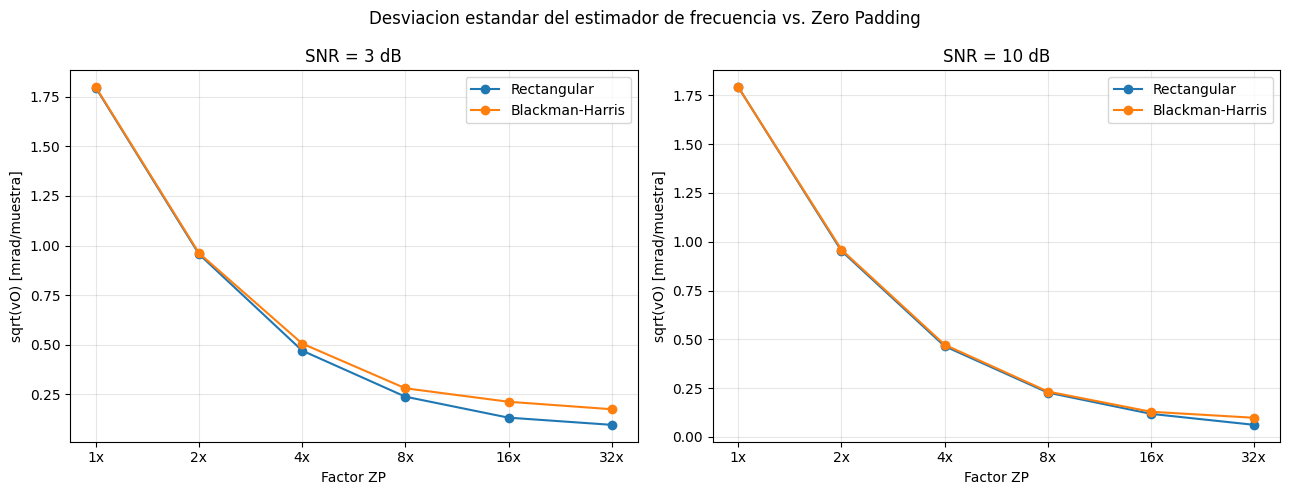

In [31]:
gammas = [1, 2, 4, 8, 16, 32]
win_plot = {'Rectangular': sig.windows.boxcar(N), 'Blackman-Harris': sig.windows.blackmanharris(N)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Desviacion estandar del estimador de frecuencia vs. Zero Padding', fontsize=12)

for ax, snr_db in zip(axes, [3, 10]):
    snr_lin = 10**(snr_db/10)
    sigma = np.sqrt(1/snr_lin)
    rng = np.random.default_rng(42)
    fr_vals = rng.uniform(-2, 2, M)
    noise = rng.normal(0, sigma, (M, N))
    Omega1_true = Omega0 + fr_vals * 2*np.pi/N

    for name, w in win_plot.items():
        stds = []
        for gamma in gammas:
            NFFT = gamma * N
            freq_est = np.empty(M)
            for j in range(M):
                x  = a0 * np.sin(Omega1_true[j] * n) + noise[j]
                Xw = np.fft.rfft(x * w, n=NFFT)
                k_m = np.argmax(np.abs(Xw))
                freq_est[j] = k_m * 2*np.pi / NFFT
            stds.append(np.std(freq_est - Omega1_true) * 1e3)
        ax.plot(gammas, stds, marker='o', label=name)

    ax.set_xscale('log', base=2)
    ax.set_xlabel('Factor ZP')
    ax.set_ylabel('sqrt(vO) [mrad/muestra]')
    ax.set_title(f'SNR = {snr_db} dB')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(gammas)
    ax.set_xticklabels([f'{g}x' for g in gammas])

plt.tight_layout()
plt.show()

## Bonus - Estimadores alternativos

Amplitud en el pico: en vez de evaluar en el bin fijo $k_0 = 250$, se evalua en el bin de maximo espectral $k_{\max}$. Elimina el sesgo por desintonía para la ventana rectangular.

Interpolacion parabolica: ajusta una parabola a los tres bins del pico para obtener una estimacion sub-bin sin zero-padding. Especialmente efectiva con ventanas de lobulo suave (Blackman-Harris, Nuttall).

In [32]:
def parabolic_interp(X_mag, k_max):
    if k_max == 0 or k_max >= len(X_mag)-1:
        return float(k_max)
    alpha, beta, gamma_v = X_mag[k_max-1], X_mag[k_max], X_mag[k_max+1]
    denom = 2*beta - alpha - gamma_v
    if denom == 0:
        return float(k_max)
    return k_max + 0.5*(alpha - gamma_v) / denom


def run_alternative(snr_db, M=200, seed=42):
    snr_lin = 10**(snr_db/10)
    sigma = np.sqrt(1/snr_lin)
    rng = np.random.default_rng(seed)
    fr_vals = rng.uniform(-2, 2, M)
    noise = rng.normal(0, sigma, (M, N))
    Omega1_true = Omega0 + fr_vals * 2*np.pi/N

    headers = ['Ventana',
               'sa fijo', 'sa pico', 'va fijo', 'va pico',
               'sO argmax[mrad]', 'sO parab[mrad]',
               'vO argmax[mrad2]', 'vO parab[mrad2]']
    rows = []
    for name, w in windows.items():
        W_sum = np.sum(w)

        amp_fixed = np.empty(M)
        amp_peak = np.empty(M)
        freq_argmax = np.empty(M)
        freq_parab = np.empty(M)

        for j in range(M):
            x = a0 * np.sin(Omega1_true[j] * n) + noise[j]
            Xw = np.fft.rfft(x * w)
            mag = np.abs(Xw)

            amp_fixed[j] = 2 * mag[k0] / W_sum
            k_max = np.argmax(mag)
            amp_peak[j] = 2 * mag[k_max] / W_sum
            freq_argmax[j] = k_max * 2*np.pi / N
            freq_parab[j] = parabolic_interp(mag, k_max) * 2*np.pi / N

        err_fam = freq_argmax - Omega1_true
        err_fpa = freq_parab  - Omega1_true

        rows.append([
            name,
            f'{np.mean(amp_fixed - a0):+.5f}',
            f'{np.mean(amp_peak  - a0):+.5f}',
            f'{np.var(amp_fixed):.2e}',
            f'{np.var(amp_peak):.2e}',
            f'{np.mean(err_fam)*1e3:+.4f}',
            f'{np.mean(err_fpa)*1e3:+.4f}',
            f'{np.var(err_fam)*1e6:.4f}',
            f'{np.var(err_fpa)*1e6:.4f}',
        ])

    print_table(headers, rows, f'Estimadores alternativos - SNR = {snr_db} dB')


run_alternative(3)
run_alternative(10)


Estimadores alternativos - SNR = 3 dB
+-----------------+----------+----------+----------+----------+-----------------+----------------+------------------+-----------------+
|     Ventana     | sa fijo  | sa pico  | va fijo  | va pico  | sO argmax[mrad] | sO parab[mrad] | vO argmax[mrad2] | vO parab[mrad2] |
+-----------------+----------+----------+----------+----------+-----------------+----------------+------------------+-----------------+
|   Rectangular   | -0.88875 | -0.17346 | 2.11e-01 | 2.24e-02 |     +0.0598     |    +0.0794     |      3.2230      |     7.0048      |
|    Flat-top     | -0.10611 | +0.00925 | 2.36e-02 | 4.34e-03 |     +0.1541     |    +0.3037     |      7.6792      |     23.9250     |
| Blackman-Harris | -0.47068 | -0.03721 | 1.32e-01 | 3.04e-03 |     +0.0598     |    +0.1011     |      3.2334      |     11.9685     |
|     Nuttall     | -0.47985 | -0.03846 | 1.35e-01 | 3.08e-03 |     +0.0598     |    +0.1010     |      3.2334      |     11.9368     |
+--------

### Discusion

El zero-padding reduce el error de cuantizacion de la grilla DFT. Sin ZP el error tiene distribucion $\sim \mathcal{U}(-\pi/N, \pi/N)$ con $\sigma_q \approx \pi/(N\sqrt{3}) \approx 1.81\,\text{mrad/m}$. Con $\gamma \geq 8$ el piso lo fija el SNR y agregar mas ceros no mejora.

La interpolacion parabolica logra precision sub-bin equivalente a $\gamma \approx 8{-}16$ sin costo computacional adicional. Con ventana rectangular el lobulo no es suave y la aproximacion parabolica es menos precisa que con Blackman-Harris o Nuttall.

## Bonus - Histogramas

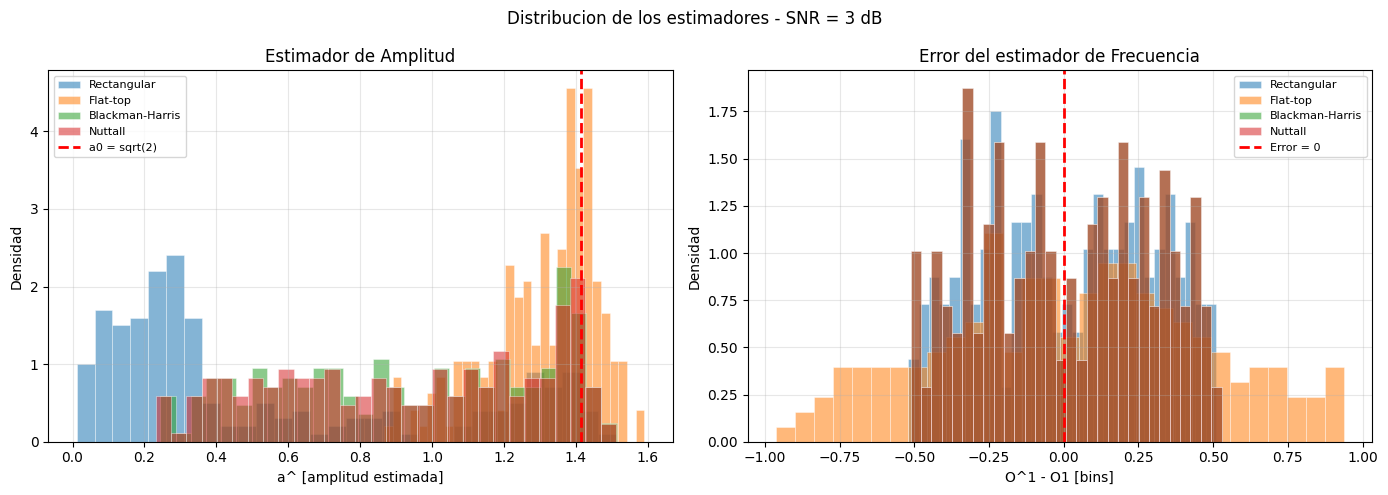

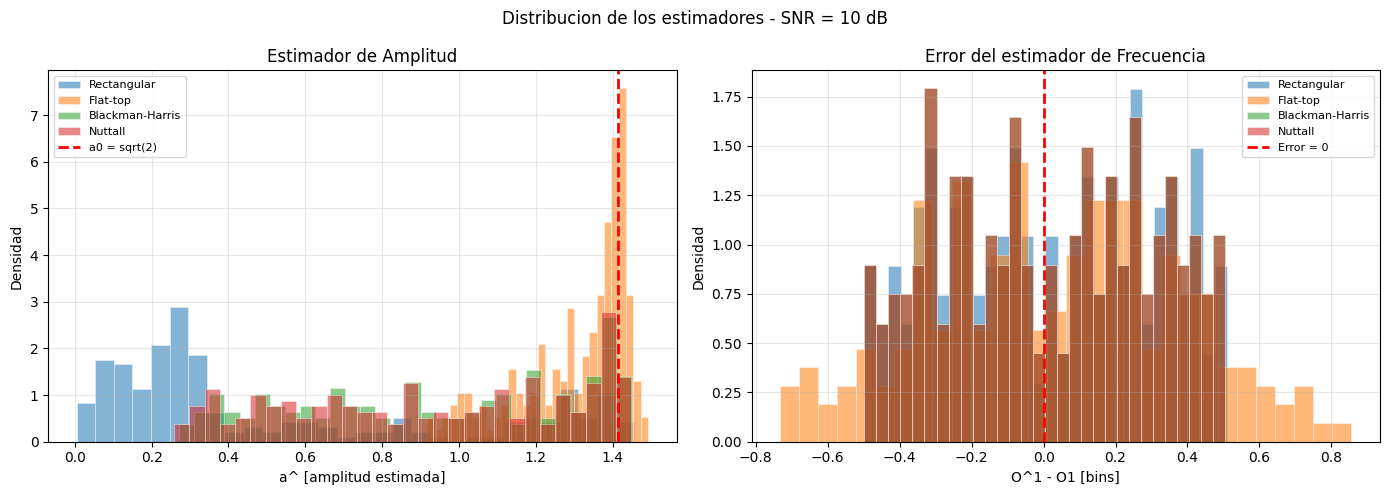

In [33]:
def plot_histograms(results, snr_db):
    win_names = list(windows.keys())
    colors_h  = ['C0', 'C1', 'C2', 'C3']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Distribucion de los estimadores - SNR = {snr_db} dB', fontsize=12)

    ax = axes[0]
    for name, color in zip(win_names, colors_h):
        ax.hist(results[name]['amp_est'], bins=30, density=True, alpha=0.55,
                label=name, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(a0, color='red', lw=2, linestyle='--', label='a0 = sqrt(2)')
    ax.set_xlabel('a^ [amplitud estimada]')
    ax.set_ylabel('Densidad')
    ax.set_title('Estimador de Amplitud')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for name, color in zip(win_names, colors_h):
        r   = results[name]
        err = (r['freq_est'] - r['Omega1_true']) * N / (2*np.pi)
        ax.hist(err, bins=30, density=True, alpha=0.55,
                label=name, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='red', lw=2, linestyle='--', label='Error = 0')
    ax.set_xlabel('O^1 - O1 [bins]')
    ax.set_ylabel('Densidad')
    ax.set_title('Error del estimador de Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_histograms(res_3dB,  3)
plot_histograms(res_10dB, 10)

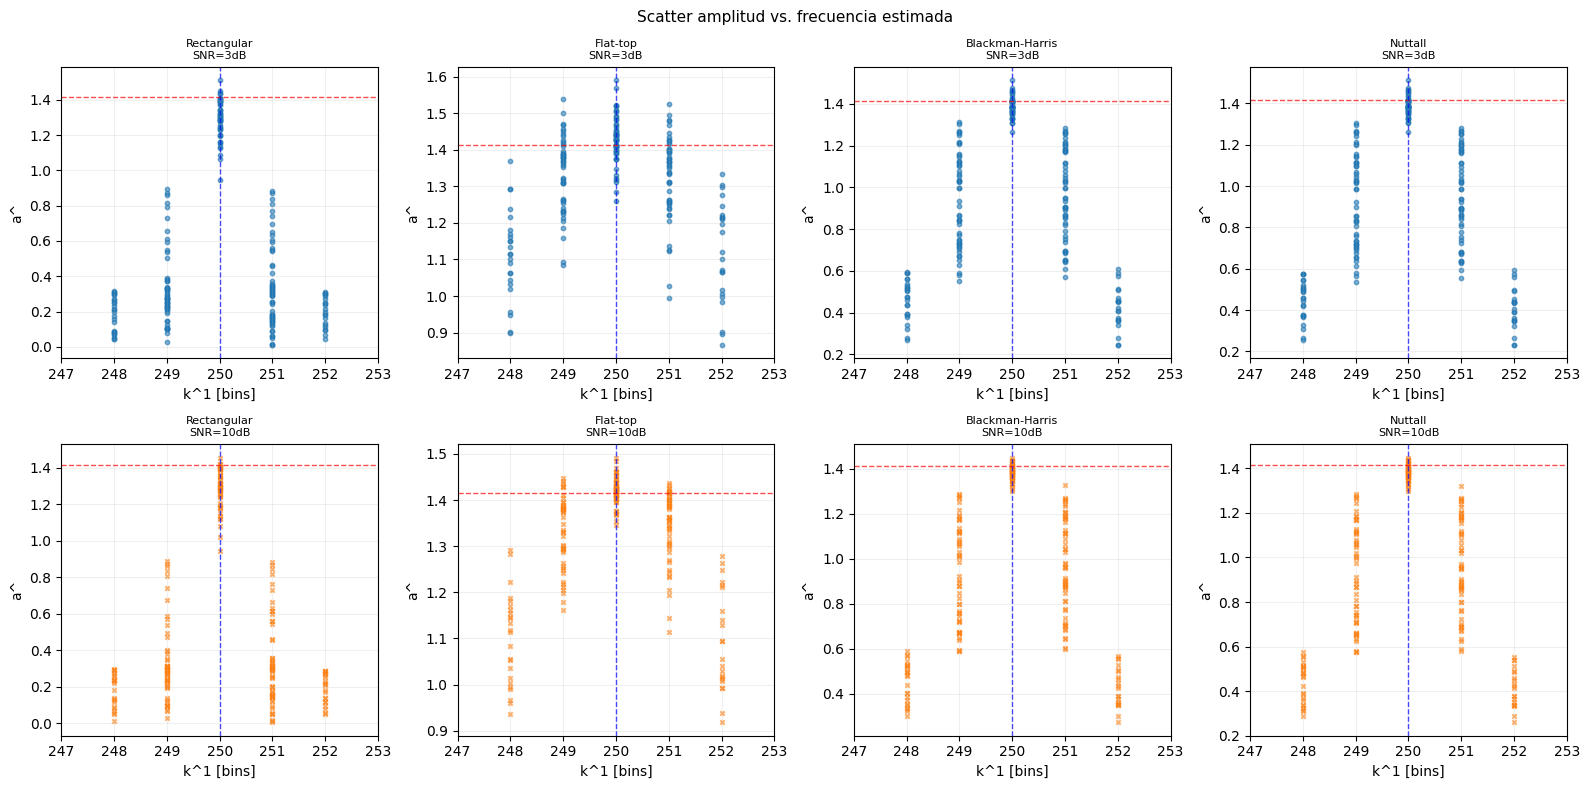

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Scatter amplitud vs. frecuencia estimada', fontsize=11)

for col, (name, w) in enumerate(windows.items()):
    for row, (res, snr_db, marker, color) in enumerate([
        (res_3dB,  3,  'o', 'C0'),
        (res_10dB, 10, 'x', 'C1'),
    ]):
        ax  = axes[row][col]
        r   = res[name]
        ax.scatter(r['freq_est'] * N / (2*np.pi), r['amp_est'],
                   s=10, alpha=0.6, marker=marker, color=color)
        ax.axhline(a0, color='red',  lw=1, ls='--', alpha=0.7)
        ax.axvline(k0, color='blue', lw=1, ls='--', alpha=0.7)
        ax.set_xlim(k0-3, k0+3)
        ax.set_xlabel('k^1 [bins]')
        ax.set_ylabel('a^')
        ax.set_title(f'{name}\nSNR={snr_db}dB', fontsize=8)
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Conclusiones

La flat-top es el mejor estimador de amplitud: sesgo minimo para cualquier desintonía $f_r \in [-2,2]$ bins gracias a su lobulo principal plano. La contrapartida es la mayor varianza en frecuencia.

La rectangular tiene la menor varianza de frecuencia (lobulo de 1 bin) pero el mayor sesgo de amplitud cuando $f_r \neq 0$.

La Blackman-Harris y Nuttall son el mejor compromiso: lobulos laterales muy bajos que reducen la interferencia entre realizaciones, con sesgo y varianza intermedios en ambos estimadores.

Al bajar el SNR de 10 dB a 3 dB la varianza de ambos estimadores crece considerablemente. El zero-padding mejora la frecuencia hasta que el piso lo fija el ruido (saturacion a partir de $\gamma \approx 8$). La interpolacion parabolica logra un efecto similar sin costo computacional.